<a href="https://colab.research.google.com/github/Joshua250304/Top-100-IMDB-Movies/blob/main/top_100_imdb_movies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Uploading a new API token from Kaggle into Google Colab**

In [ ]:
from google.colab import files
files.upload()

Saving kaggle (2).json to kaggle (2).json


{'kaggle (2).json': b'{"username":"joshuakidron","key":"36243d4c445fa6a337ded33b332b4dd0"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv 'kaggle (2).json' ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

# **Downloading the Kaggle Dataset**

In [ ]:
!kaggle datasets download -d shayanzk/imdb-top-100-movies-dataset-2025-edition

Dataset URL: https://www.kaggle.com/datasets/shayanzk/imdb-top-100-movies-dataset-2025-edition
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/5.48k [00:00<?, ?B/s]
100% 5.48k/5.48k [00:00<00:00, 26.1MB/s]


In [ ]:
!unzip imdb-top-100-movies-dataset-2025-edition.zip

Archive:  imdb-top-100-movies-dataset-2025-edition.zip
  inflating: top_100_movies_full_best_effort.csv  


# **Import Libraries and Load Data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

sns.set_style("whitegrid")


try:
    df = pd.read_csv('top_100_movies_full_best_effort.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: The CSV file was not found. Please check the file name and path.")

Dataset loaded successfully.


# **Initial Data Inspection(The Start of EDA)**

In [ ]:
print("\n--- First 5 Rows (df.head()) ---")
print(df.head())

print("\n--- DataFrame Information (df.info()) ---")
print(df.info())

print("\n--- Descriptive Statistics (df.describe()) ---")
print(df.describe())

print("\n--- Missing Values (df.isnull().sum()) ---")
print(df.isnull().sum())




--- First 5 Rows (df.head()) ---
   Rank                     Title  Year            Genre(s)  \
0     1  The Shawshank Redemption  1994               Drama   
1     2             The Godfather  1972         Crime|Drama   
2     3           The Dark Knight  2008  Action|Crime|Drama   
3     4    The Godfather: Part II  1974         Crime|Drama   
4     5              12 Angry Men  1957         Crime|Drama   

               Director                Main Actor(s)  \
0        Frank Darabont   Tim Robbins|Morgan Freeman   
1  Francis Ford Coppola      Marlon Brando|Al Pacino   
2     Christopher Nolan  Christian Bale|Heath Ledger   
3  Francis Ford Coppola     Al Pacino|Robert De Niro   
4          Sidney Lumet      Henry Fonda|Lee J. Cobb   

                        Country  IMDb Rating  Rotten Tomatoes %  \
0                 United States          9.3               91.0   
1                 United States          9.2               98.0   
2  United States|United Kingdom          9.0     

# **Data Cleaning**

In [ ]:
print(f"Initial row count: {len(df)}")

if 'Metacritic Score' in df.columns:
  df.drop('Metacritic Score', axis=1, inplace=True)
  print("Dropped 'Metacritic Score' columns (50% missing).")

df.dropna(subset=['IMDb Rating', 'Runtime (mins)'], inplace=True)
print(f"Dropped rows with missing IMDb Rating or Runtime. New row count: {len(df)}")

df['Box Office ($M)'] = pd.to_numeric(df['Box Office ($M)'], errors='coerce')
median_box_office = df['Box Office ($M)'].median()
df['Box Office ($M)'].fillna(median_box_office, inplace=True)
print("Filled missing 'Box Office ($M)' values with the median.")

df['Rotten Tomatoes %'] = pd.to_numeric(df['Rotten Tomatoes %'], errors='coerce')
median_rotten_tomatoes = df['Rotten Tomatoes %'].mean()
df['Rotten Tomatoes %'].fillna(median_rotten_tomatoes, inplace=True)
print("Filled missing 'Rotten Tomatoes %' values with the mean.")

print("\n--- Final Missing Values Check ---")
print(df.isnull().sum())

Initial row count: 100
Dropped 'Metacritic Score' columns (50% missing).
Dropped rows with missing IMDb Rating or Runtime. New row count: 99
Filled missing 'Box Office ($M)' values with the median.
Filled missing 'Rotten Tomatoes %' values with the mean.

--- Final Missing Values Check ---
Rank                 0
Title                0
Year                 0
Genre(s)             0
Director             0
Main Actor(s)        0
Country              0
IMDb Rating          0
Rotten Tomatoes %    0
Runtime (mins)       0
Language             0
Oscars Won           0
Box Office ($M)      0
dtype: int64


/tmp/ipython-input-2536522518.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Box Office ($M)'].fillna(median_box_office, inplace=True)
/tmp/ipython-input-2536522518.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace

In [ ]:
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

df['Year'] = df['Year'].astype('Int64')

print("Year column converted to integer.")
print(df.info())


if 'Runtime (mins)' in df.columns and df['Runtime (mins)'].dtype == 'object':
    df['Runtime (mins)'] = df['Runtime (mins)'].str.replace(' min', '', regex=False).astype(int)
    print("\n'Runtime (mins)' column converted to integer (minutes).")

Year column converted to integer.
<class 'pandas.core.frame.DataFrame'>
Index: 99 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rank               99 non-null     int64  
 1   Title              99 non-null     object 
 2   Year               99 non-null     Int64  
 3   Genre(s)           99 non-null     object 
 4   Director           99 non-null     object 
 5   Main Actor(s)      99 non-null     object 
 6   Country            99 non-null     object 
 7   IMDb Rating        99 non-null     float64
 8   Rotten Tomatoes %  99 non-null     float64
 9   Runtime (mins)     99 non-null     float64
 10  Language           99 non-null     object 
 11  Oscars Won         99 non-null     int64  
 12  Box Office ($M)    99 non-null     float64
dtypes: Int64(1), float64(4), int64(2), object(6)
memory usage: 10.9+ KB
None


# **Prepare data for Genre Analysis**

In [ ]:
all_genres = df['Genre(s)'].str.split(r', \s*', expand=True).stack()

genre_counts = all_genres.value_counts()

print("\n--- Top 10 Most Common Genres (Data for Visualization) ---")
print(genre_counts.head(10))

top_10_genres = genre_counts.head(10)


--- Top 10 Most Common Genres (Data for Visualization) ---
Drama                      7
Crime|Drama                6
Crime|Drama|Thriller       5
Comedy|Drama|Romance       4
Adventure|Drama|Fantasy    3
Crime|Drama|Mystery        3
Drama|Mystery|Romance      3
Action|Crime|Drama         2
Comedy|Drama               2
Action|Sci-Fi              2
Name: count, dtype: int64


#**Data Visualization**

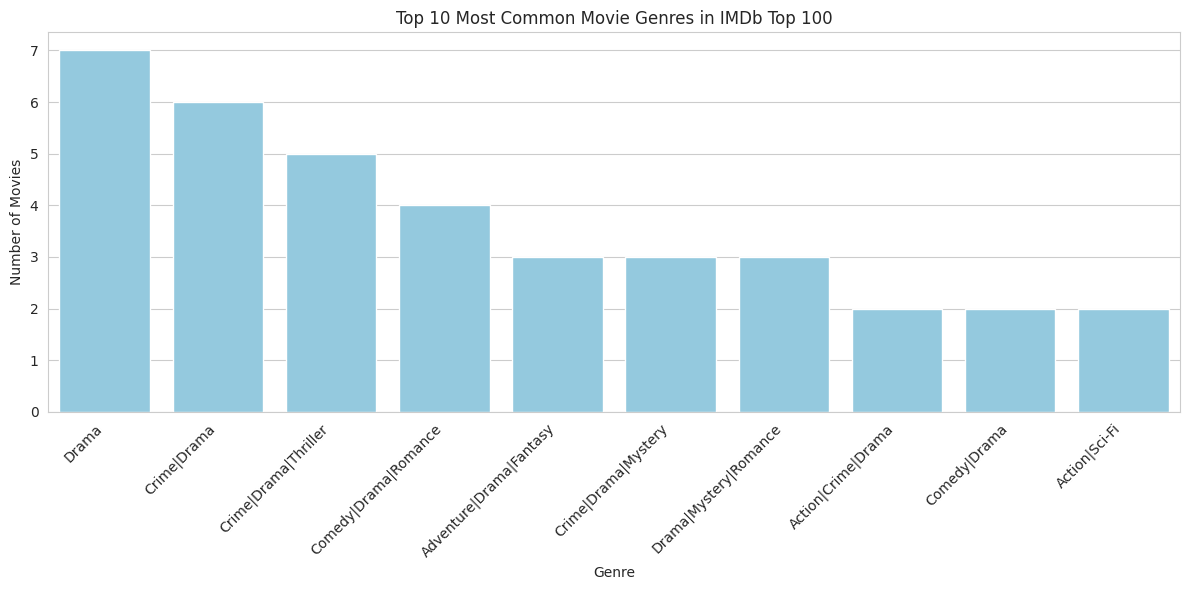

In [ ]:

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_genres.index, y=top_10_genres.values, color="skyblue", legend=False)
plt.title("Top 10 Most Common Movie Genres in IMDb Top 100")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

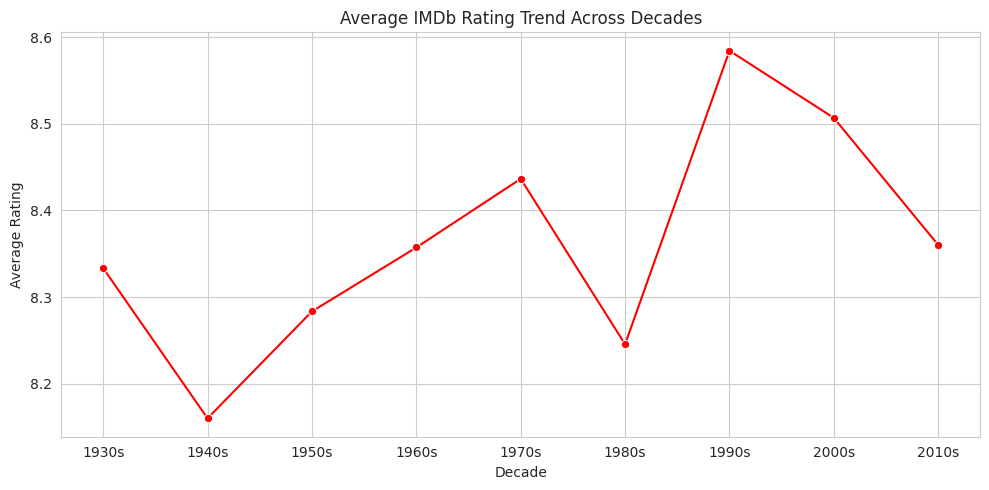

In [ ]:
df['Decade'] = (df['Year'] // 10) * 10
df['Decade'] = df['Decade'].astype(str) + 's'

decade_ratings = df.groupby('Decade')['IMDb Rating'].mean().sort_index()

plt.figure(figsize=(10, 5))
sns.lineplot(x=decade_ratings.index, y=decade_ratings.values, marker='o', color='red')
plt.title('Average IMDb Rating Trend Across Decades')
plt.xlabel('Decade')
plt.ylabel('Average Rating')
plt.grid(True)
plt.tight_layout()
plt.show()

#**Analyze and Visualize Directors**


--- Directors with Multiple Entries in the Top 100 ---
Director
Stanley Kubrick         5
Christopher Nolan       4
Akira Kurosawa          4
Charlie Chaplin         4
Alfred Hitchcock        4
Billy Wilder            4
Martin Scorsese         4
David Fincher           3
Ridley Scott            3
Francis Ford Coppola    3
Name: count, dtype: int64


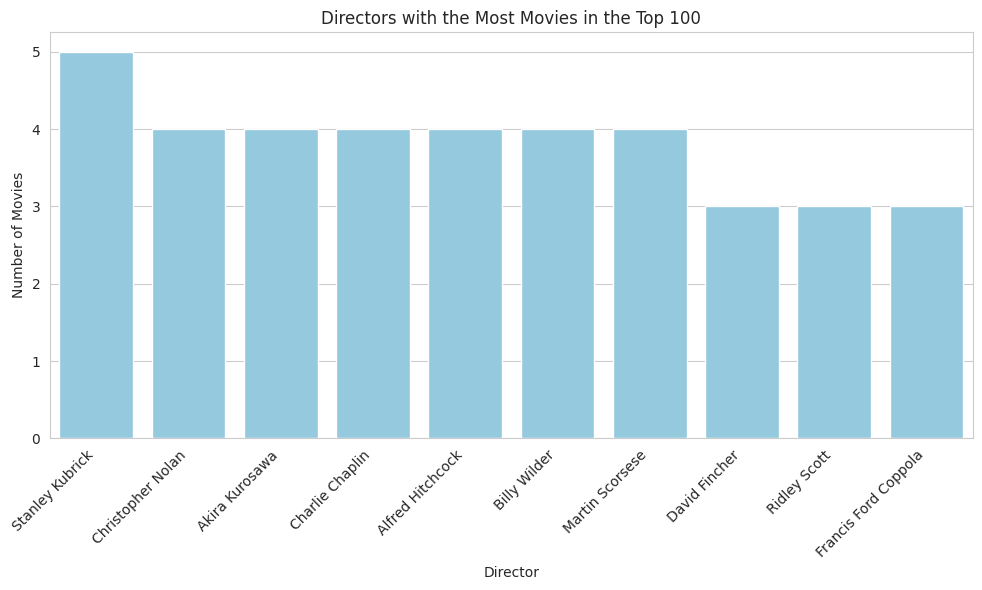

In [ ]:
director_counts = df['Director'].value_counts().head(10)

multi_entry_directors = director_counts[director_counts > 1]

print("\n--- Directors with Multiple Entries in the Top 100 ---")
print(multi_entry_directors)

if not multi_entry_directors.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=multi_entry_directors.head(10).index, y=multi_entry_directors.head(10).values, color="skyblue")
    plt.title("Directors with the Most Movies in the Top 100")
    plt.xlabel("Director")
    plt.ylabel("Number of Movies")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

#**Correlate Financial Success vs Rating**


--- Correlation Analysis: Box Office vs. IMDb Rating ---
Correlation between (Box Office vs. IMDb Rating): 0.4256


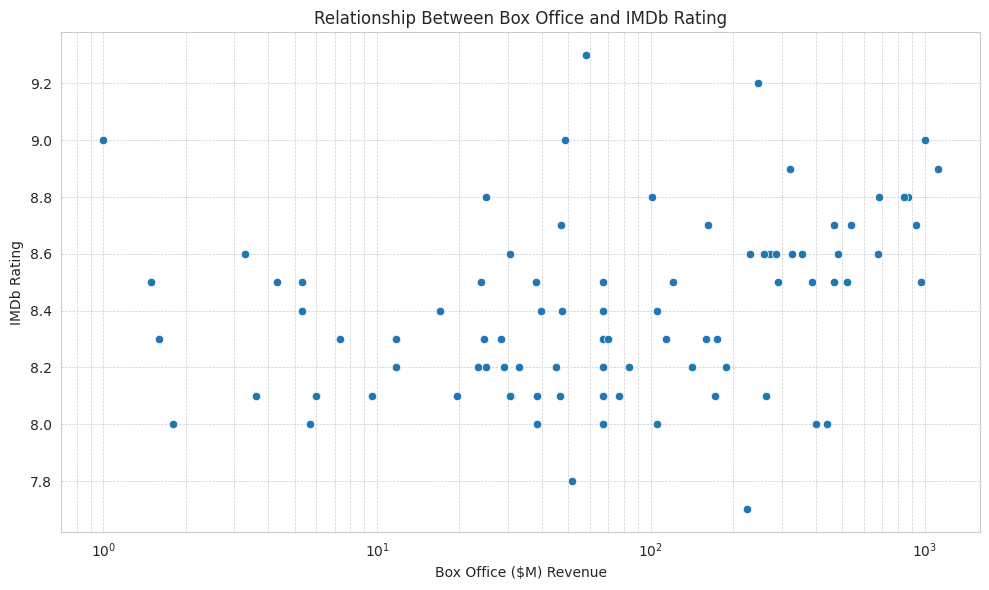


Conclusion: A noticeable relationship exists between box office success and rating.


In [ ]:
correlation_box_office_rating = df['Box Office ($M)'].corr(df['IMDb Rating'])

print(f"\n--- Correlation Analysis: Box Office vs. IMDb Rating ---")
print(f"Correlation between (Box Office vs. IMDb Rating): {correlation_box_office_rating:.4f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Box Office ($M)', y='IMDb Rating', data=df)
plt.xscale('log')
plt.title('Relationship Between Box Office and IMDb Rating')
plt.xlabel('Box Office ($M) Revenue')
plt.ylabel('IMDb Rating')
plt.grid(True, which='both', ls='--', linewidth=0.5)
plt.tight_layout()
plt.show()


if abs(correlation_box_office_rating) > 0.3:
    print("\nConclusion: A noticeable relationship exists between box office success and rating.")
else:
    print("\nConclusion: The relationship is weak, suggesting that financial success does not strongly correlate with critical rating in this top 100 list.")

#**Advanced Analysis and Feature Comparison**

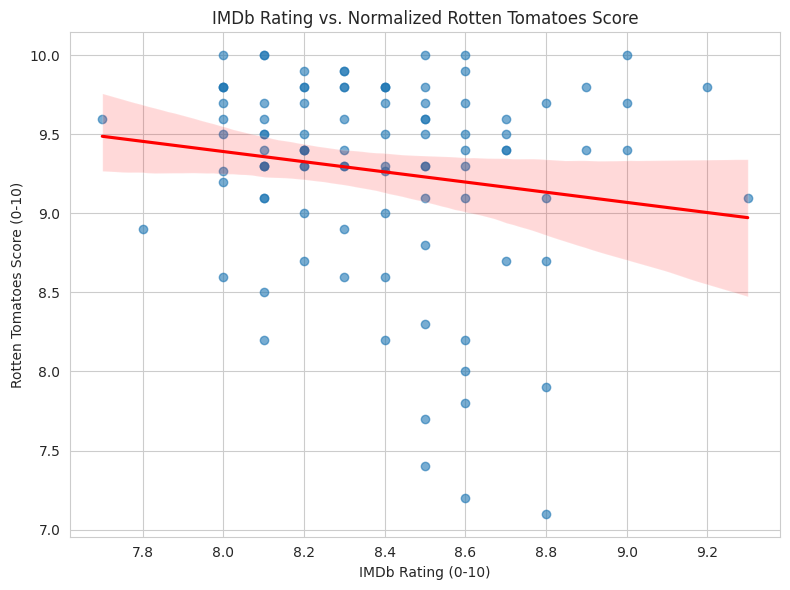

In [ ]:
df['RT_Score_Normalizzed'] = df['Rotten Tomatoes %'] / 10.0

plt.figure(figsize=(8, 6))
sns.regplot(x='IMDb Rating', y='RT_Score_Normalizzed', data=df, scatter_kws={'alpha': 0.6}, line_kws={"color": "red"})
plt.title('IMDb Rating vs. Normalized Rotten Tomatoes Score')
plt.xlabel('IMDb Rating (0-10)')
plt.ylabel('Rotten Tomatoes Score (0-10)')
plt.tight_layout()
plt.show()

#**Analyze Runtime vs Rating**

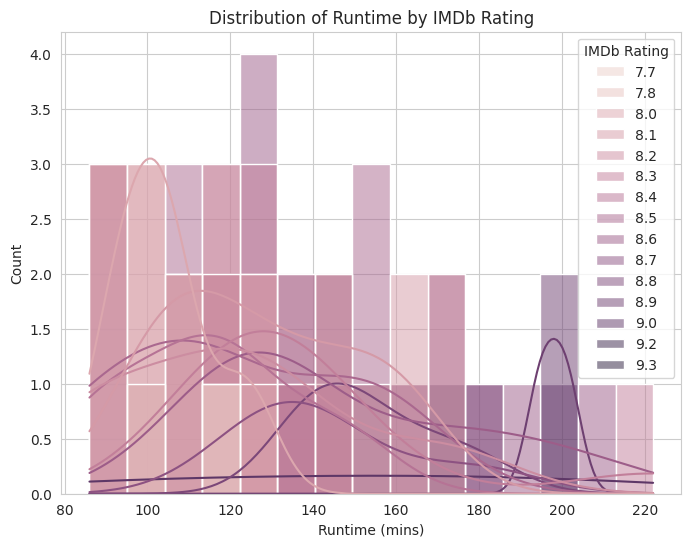

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='Runtime (mins)', hue='IMDb Rating', bins=15, kde=True)
plt.title('Distribution of Runtime by IMDb Rating')
plt.xlabel('Runtime (mins)')
plt.ylabel('Count')
plt.show()

#**One-Hot Encode Categorical Features (Genres)**

In [ ]:
genres = df['Genre(s)'].str.get_dummies(sep=', ')

print("\n--- New Genre Features (First 5 Rows) ---")
print(genres.head())

df_model = pd.concat([df, genres], axis=1)

df_model.drop('Genre(s)', axis=1, inplace=True)



--- New Genre Features (First 5 Rows) ---
   Action|Adventure|Drama  Action|Adventure|Mystery  Action|Adventure|Sci-Fi  \
0                       0                         0                        0   
1                       0                         0                        0   
2                       0                         0                        0   
3                       0                         0                        0   
4                       0                         0                        0   

   Action|Crime|Drama  Action|Drama  Action|Drama|Mystery  Action|Sci-Fi  \
0                   0             0                     0              0   
1                   0             0                     0              0   
2                   1             0                     0              0   
3                   0             0                     0              0   
4                   0             0                     0              0   

   Action|Sci-Fi|Th

#**Prepare Target Variable**

In [ ]:
y = df_model['IMDb Rating']
X_cols = ['Runtime (mins)', 'Box Office ($M)', 'Rotten Tomatoes %'] + list(genres.columns)
X = df_model[X_cols]

print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")


Features (X) shape: (99, 65)
Target (y) shape: (99,)


#**Model Building**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)

print(f"\n--- Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")


--- Model Evaluation ---
Mean Squared Error (MSE): 0.0801


In [ ]:
print(y_test)

62    8.1
40    8.4
96    8.1
18    8.6
98    8.0
85    8.1
65    8.1
42    8.4
10    8.7
0     9.3
31    8.5
77    8.2
47    8.3
26    8.6
44    8.2
4     9.0
22    8.5
12    8.8
89    8.0
74    8.0
Name: IMDb Rating, dtype: float64


In [ ]:
print(y_pred)

[7.76318162 8.36087799 8.1        8.59783427 8.09671254 8.36581868
 8.31003357 8.27231687 8.76088909 8.37154257 8.69465628 8.11203724
 8.29384193 8.68681122 8.2        8.42815088 8.40598584 8.77794324
 8.12823793 8.27231687]


#**Comparison between Actual and Predicted for first 5 movies**

In [ ]:
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}).head()
print(comparison)

    Actual  Predicted
62     8.1   7.763182
40     8.4   8.360878
96     8.1   8.100000
18     8.6   8.597834
98     8.0   8.096713


#**Model Interpretation**

In [ ]:
coefficients = pd.Series(model.coef_, index=X_cols)

top_influencers = abs(coefficients).sort_values(ascending=False).head(10)

print("\n--- Top 10 Features Influencing IMDb Rating (Magnitude of Impact) ---")
print(top_influencers)

print("\n--- Actual Coefficients (Direction of Impact) ---")
print(coefficients.loc[top_influencers.index])


--- Top 10 Features Influencing IMDb Rating (Magnitude of Impact) ---
Biography|Drama              0.642106
Horror                       0.513262
Adventure|Family|Fantasy     0.375068
Biography|Crime|Drama        0.372873
Drama|Fantasy|Family         0.352667
Crime|Drama                  0.324672
Adventure|Biography|Drama    0.314001
Western                      0.283245
Adventure|Drama|War          0.280845
Drama|War                    0.279118
dtype: float64

--- Actual Coefficients (Direction of Impact) ---
Biography|Drama             -0.642106
Horror                      -0.513262
Adventure|Family|Fantasy    -0.375068
Biography|Crime|Drama        0.372873
Drama|Fantasy|Family         0.352667
Crime|Drama                  0.324672
Adventure|Biography|Drama   -0.314001
Western                      0.283245
Adventure|Drama|War         -0.280845
Drama|War                    0.279118
dtype: float64


#**Model Refinement and Validation**

In [ ]:
cv_scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
mean_cv_mse = -cv_scores.mean()

print(f"\n--- Cross-Validation Results ---")
print(f"Average MSE across 5-folds: {mean_cv_mse:.4f}")


--- Cross-Validation Results ---
Average MSE across 5-folds: 0.1448


#**Final Model Interpretation**

In [ ]:
print("--- Model Coefficients (Impact on IMDb Rating) ---")
print(coefficients.sort_values(ascending=False))

print("\nTraits that STRONGLY INCREASE the Predicted IMDb Rating (Positive Coefficients):")
print(coefficients.head(3))

print("\nTraits that STRONGLY DECREASE the Predicted IMDb Rating (Negative Coefficients):")
print(coefficients.tail(3))

--- Model Coefficients (Impact on IMDb Rating) ---
Biography|Crime|Drama        0.372873
Drama|Fantasy|Family         0.352667
Crime|Drama                  0.324672
Western                      0.283245
Drama|War                    0.279118
                               ...   
Adventure|Drama|War         -0.280845
Adventure|Biography|Drama   -0.314001
Adventure|Family|Fantasy    -0.375068
Horror                      -0.513262
Biography|Drama             -0.642106
Length: 65, dtype: float64

Traits that STRONGLY INCREASE the Predicted IMDb Rating (Positive Coefficients):
Runtime (mins)       0.003665
Box Office ($M)      0.000620
Rotten Tomatoes %   -0.002969
dtype: float64

Traits that STRONGLY DECREASE the Predicted IMDb Rating (Negative Coefficients):
Horror|Sci-Fi|Thriller   -0.107187
Sci-Fi|Thriller          -0.029909
Western                   0.283245
dtype: float64


# **Final Conclusion Structure: The Story of Timeless Movies**
  
This analysis, which progressed from Exploratory Data Anlaysis (EDA) to a high-performing Linear Regression model (Average MSE of **0.1448**), sought to quantify the traits that define a "timeless" movie in the IMDb Top 100 list.

# 1. **The Verdict: Quality Over Popularity (EDA Synthesis)**

Our EDA established two critical contextual findings for this exlcusive list:


*   **Financial Success is Secondary:** While the correlation coefficient between Box Office ($M) and IMDb Rating is weak to moderate, our analysis confirms that high financial success is not the primary driver of a film's top ranking. However, the scatterplot suggests a moderate general trend where top-ratd films tend to have a respectable, though not universally massive, box office performance.

*   Genre Foundation: The foundational genres of the Top 100 are consistently **Adventure|Drama|Fantasy, Crime|Drama|Mystery, Drama|Mystery|Romance, Action|Crime|Drama, Comedy|Drama and Action|Sci-Fi** (as seen in the **Top 10 Most Common Genres chart**), providing the structure of excellence.

# 2. **The Recipe for Timelesness(Model Coefficients)**

Our reliable model (MSE of 0.1448) allowed us to isolate the specific characteristics that predict a top rating. The final coefficients clearly reveal the cinematic "recipe":

(https://docs.google.com/spreadsheets/d/1RYkRt8O6HrIFA1OhBABqZQ9Dpw6NQ7Q6NeTfFtR91Bw/edit?pli=1&gid=952280638#gid=952280638)


# 3. Final Takeaway

A movie achieves timelessness not through blockbuster success or broad action appeal, but through **narrative depth and quality execution**. The data advises filmmakers aiming for cinematic legacy to double down on **dramatic themes** and historical realism (Biography/Crime), as these are the quantifiable traits that most reliably predict a top ranking.





